# Claims Damage Ratio Prediction

This notebook demonstrates the process of training a machine learning model to predict the damage ratio for insurance claims using cleaned claims data. The workflow includes data loading, preprocessing, model training with hyperparameter optimization, evaluation, and visualization of results.

In [43]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import optuna
import lightgbm as lgb

## 1.1. Load Data and Prepare Features

Read the cleaned claims data and split it into features and target for model training and evaluation.

In [30]:
df = pd.read_csv("data/claims_cleaned.csv")
categorical_features = [
    'ratedFloodZone', 'occupancyType', 'basement', 
    'countyCode', 'elevatedBuildingIndicator'
]

target = "damageRatio"
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 30)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = 30)

## 1.2. Hyperparameter Tuning with Optuna

Define the objective function and use Optuna to search for the best LightGBM hyperparameters that minimize the RMSE on the validation set.

In [ ]:
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1),
        "num_leaves": trial.suggest_int("num_leaves", 16, 1024),
        "max_depth": trial.suggest_int("max_depth", 2, 32),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.33, 1.0)
    }

    dtrain = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=categorical_features)
    
    dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    base_model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid]
    )

    preds = base_model.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    return rmse

study = optuna.create_study(direction = "minimize")
study.optimize(objective, n_trials = 50)

print("Best RMSE:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-09-18 21:28:28,727] A new study created in memory with name: no-name-a40a45bd-da09-42d3-9d0e-8062e507c7fe
[I 2025-09-18 21:28:35,053] Trial 0 finished with value: 0.2231783310057067 and parameters: {'learning_rate': 0.00891741931488122, 'num_leaves': 590, 'max_depth': 21, 'min_data_in_leaf': 34, 'feature_fraction': 0.8254133625914415}. Best is trial 0 with value: 0.2231783310057067.
[I 2025-09-18 21:28:35,194] Trial 1 finished with value: 0.23378532925650794 and parameters: {'learning_rate': 0.02246664842967857, 'num_leaves': 751, 'max_depth': 2, 'min_data_in_leaf': 29, 'feature_fraction': 0.5785539762976265}. Best is trial 0 with value: 0.2231783310057067.
[I 2025-09-18 21:28:39,207] Trial 2 finished with value: 0.20794009444630043 and parameters: {'learning_rate': 0.08358141867133626, 'num_leaves': 556, 'max_depth': 19, 'min_data_in_leaf': 56, 'feature_fraction': 0.4230450920653102}. Best is trial 2 with value: 0.20794009444630043.
[I 2025-09-18 21:28:48,046] Trial 3 finished

Best RMSE: 0.20635958243079894
Best Params: {'learning_rate': 0.09657204203426059, 'num_leaves': 228, 'max_depth': 24, 'min_data_in_leaf': 52, 'feature_fraction': 0.6711714245545851}


### 1.2.1. Update Model Parameters

Update the model parameters with the best values found by Optuna for final training.

In [7]:
# Update tuned params
best_params = study.best_params
best_params["objective"] = "regression"
best_params["metric"] = "rmse"
best_params["verbosity"] = -1

with open('models/best_params_base.json', 'w') as f:
    json.dump(best_params, f)


## 1.3. Train Final Model

Train the LightGBM model using the best hyperparameters on the full training data and save the trained model to disk.

In [35]:
X_test_base = X_test.copy()
y_test_base = y_test.copy()

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

dtrain_full = lgb.Dataset(X_full, label = y_full, 
                          categorical_feature=categorical_features)
dval_full = lgb.Dataset(X_val, label = y_val, reference=dtrain_full)
dtest = lgb.Dataset(X_test_base, label=y_test_base)

In [32]:
# Train final model
tuned_model = lgb.train(
    params=best_params,
    train_set=dtrain_full,
    num_boost_round=5000,
    valid_sets=[dtrain_full, dtest],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Save model to file
model_path = 'models/base_lgb_model.txt'
tuned_model.save_model(model_path)

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.186329	test's rmse: 0.206541
Early stopping, best iteration is:
[80]	train's rmse: 0.188658	test's rmse: 0.206456


## 1.4. Evaluate Model on Test Set

Generate predictions on the test set and compute the root mean squared error to assess model performance.

RMSE on the train set is 0.18850
RMSE on the val set is 0.18989
RMSE on the train + val set is 0.18866
RMSE on the test set is 0.20646


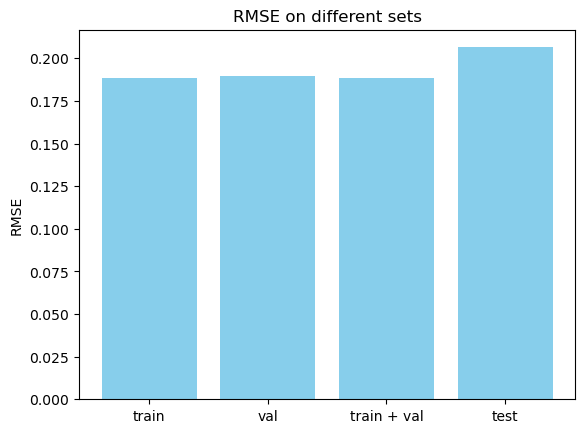

In [ ]:
sets = {'train': (X_train, y_train), 
        'val': (X_val, y_val), 
        'train + val': (X_full, y_full), 
        'test': (X_test_base, y_test_base)}

rmses = {}
predictions = {}
for set, (x,y) in sets.items():
    preds = tuned_model.predict(x)
    rmse = root_mean_squared_error(y, preds)
    predictions[set] = preds
    rmses[set] = rmse
    print(f"RMSE on the {set} set is {rmse:.5f}")

plt.bar(rmses.keys(), rmses.values(), color='skyblue')
plt.ylabel('RMSE')
plt.title('RMSE on different sets')
plt.show()


### 1.4.1 Visualize Predictions

Create a scatter plot comparing the true and predicted damage ratios for the test set, and display the $R^2$ score.

/var/folders/9v/gbghw4697p5219tnn983g81w0000gn/T/ipykernel_24379/934928796.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/9v/gbghw4697p5219tnn983g81w0000gn/T/ipykernel_24379/934928796.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


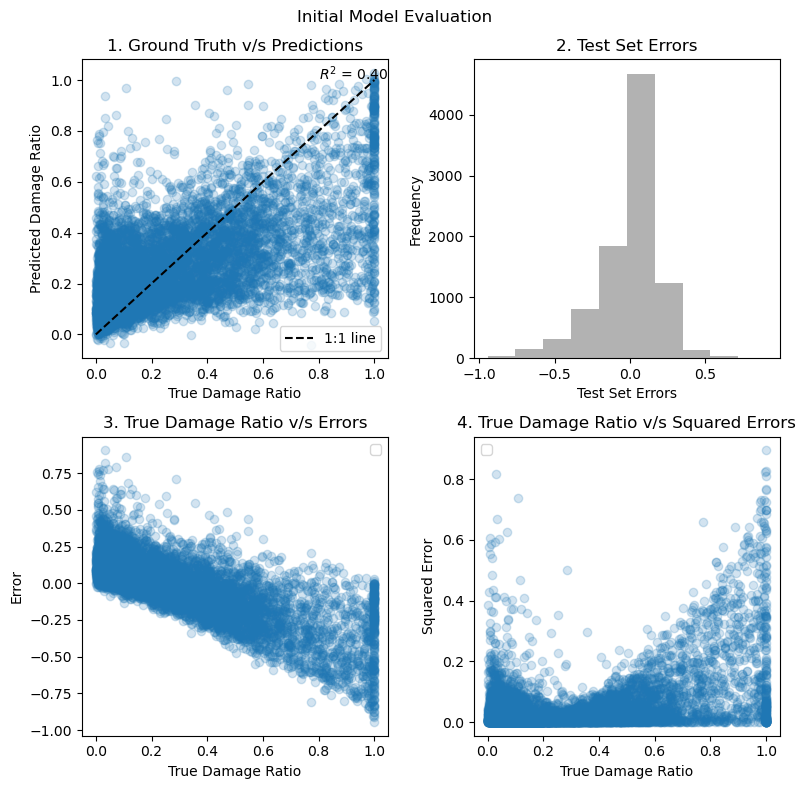

In [39]:
# Plot predictions 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

errors = predictions['test'] - y_test_base
squared_errors = errors**2

plt.figure(figsize = (8,8))
plt.suptitle('Initial Model Evaluation')
# 1. Ground Truth v/s Predictions
plt.subplot(2,2,1)
plt.scatter(y_test, predictions['test'], alpha = 0.2)
plt.plot([0,1], [0,1], color='black', linestyle='--', label='1:1 line')  # Diagonal line for reference
plt.xlabel('True Damage Ratio')
plt.ylabel('Predicted Damage Ratio')
plt.legend()
plt.text(0.8, 1, f'$R^2$ = {r2_score(y_test, preds):.2f}')
plt.title(f'1. Ground Truth v/s Predictions')
plt.savefig('plots/inital_model_predictions_vs_ground_truth.png')

# 2. Distribution of errors
plt.subplot(2,2,2)
plt.hist(errors, color = 'black', alpha = 0.3)
plt.xlabel('Test Set Errors')
plt.ylabel('Frequency')
plt.title('2. Test Set Errors')

# 3. Damage Ratio v/s Errors
plt.subplot(2,2,3)
plt.scatter(y_test_base, errors, alpha = 0.2)
plt.xlabel('True Damage Ratio')
plt.ylabel('Error')
plt.legend()
plt.title('3. True Damage Ratio v/s Errors')

# 4. Damage Ratio v/s Squared Errors
plt.subplot(2,2,4)
plt.scatter(y_test_base, squared_errors, alpha = 0.2)
plt.xlabel('True Damage Ratio')
plt.ylabel('Squared Error')
plt.legend()
plt.title('4. True Damage Ratio v/s Squared Errors')

plt.tight_layout()
plt.savefig('plots/inital_model_evaluation.png')


In [47]:
# compile test set metrics

test_set_metrics_base = {
    'RMSE':rmses['test'],
    'R2':r2_score(y_test_base, predictions['test']),
    'Bias':np.mean(predictions['test'] - y_test_base),
}

test_set_metrics_base

{'RMSE': 0.20645590108662756,
 'R2': 0.3970097415259153,
 'Bias': np.float64(-0.0013636203255563298)}

## 1.5. Conclusions

### 1.5.1 Ground Truth v/s Predictions 
* $R^2$ = 0.4 indicates **only 40% of the variance in damage ratio is captured in our model**.
* The predictions fan out for high damage ratios indicating the **model underfits for higher damage ratios**.

### 1.5.2  Error Distribution
* Errors roughly center on zero. However, the tails are heavy meaning that while most errors are small, a non-negligible fraction of errors is very high.

### 1.5.3. True Damage Ratio v/s Errors
* A clear downward trend: at higher true damage ratios the errors are systematically negative (i.e. the model under-predicts large losses).
* At low true values it slightly over-predicts. This is classic **regression-to-the-mean bias**.

### 1.5.4. True Damage Ratio v/s Squared Errors
* Squared errors grow with true damage - the “fan” shape of **heteroskedasticity**.
* Variance of the noise is non-constant: high‐damage cases are both more biased and more variable.


---

# 2. Transition to a Two-Stage Modeling Framework


## Why a Two-Stage Modeling Framework?  

The diagnostics from our initial LightGBM fit reveal three critical issues:  

1. **Under-fitting at the extremes**  

   * $R^2$ ~ 0.40 and the “Predicted vs. True” scatter show the model captures only the central mass of the data, systematically under-predicting high damage ratios and over-predicting low ones.  

2. **Regression-to-the-mean bias**  

   * The “True vs. Error” plot slopes downward: large true values incur large negative errors and vice versa.  

3. **Heteroskedastic noise**  

   * The “True vs. Squared Error” plot fans out as damage increases, indicating that error variance grows with the target.  

---

### Two-Stage Pipeline to Address These Issues  

1. **Smooth Baseline Fit**  

   Fit a non-parametric spline on `waterDepth` $\rightarrow$ `damageRatio` to capture the dominant, predictable trend and remove the bulk of the depth effect.  

2. **Residual-Mean Model** 

   Train a LightGBM on the signed residuals  
   
   $r_i = y_i - \hat{\text{baseline}}(x_i)$

   to learn the systematic under- and over-predictions left by the baseline.  

3. **Variance-Aware Weighting**  

   Estimate the local noise level $(\hat\sigma^2(x))$ by modeling squared residuals, then use inverse-variance weights  

   $w_i = \frac{1}{\hat\sigma^2(x_i)}$

   when retraining the residual model. This down-weights high-variance (noisy) points and focuses learning on reliable patterns.

Together, this “mean + deviation + variance” framework directly neutralizes bias at the extremes **and** accounts for non-constant noise, delivering a more accurate, unbiased damage-ratio predictor.  

---


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

## 2.1 Baseline Model 
Fit a smooth spline baseline model to capture the mean trend on `waterDepth`

In [40]:
# Fit a baseline model using a spline on water depth to capture it's impact on damageRatio
def evaluate_spline(knots, degree):

    baseline_pipe = Pipeline([
        ('spline', SplineTransformer(knots, degree)),
        ('linreg', LinearRegression()),
     ])
    
    baseline_pipe.fit(
        X_train[['waterDepth']],
        y_train
    )

    preds = baseline_pipe.predict(X_val[['waterDepth']])
    score = root_mean_squared_error(y_val, preds)

    return score

knots = range(2, 16)
degree = range(1, 4)
scores = {}

best_score = 1
early_stop_tol = 1e-3
best_pipeline_params = (2, 1)

print('TUNING BASELINE MODEL PARAMS USING GRID SEARCH')
for knot in knots:
    for deg in degree:
        score = evaluate_spline(knot, deg)
        
        if score < best_score:
            if best_score - score < 1e-4:
                break
            else:
                best_score = score
                best_pipeline_params = (knot, deg)
                print(f'[NEW BEST SCORE] {knot} knots, {deg} degree: Score = {score:.4f}, Best = {best_score:.4f}')
print('---')
print(f'BEST PARAMS FOR THE BASELINE PIPELINE - {knot, deg}')
knots, degree = best_pipeline_params
baseline_pipe = Pipeline([
        ('spline', SplineTransformer(knots, degree)),
        ('linreg', LinearRegression())
    ])
baseline_pipe.fit(X_train[['waterDepth']], y_train)


for X in [X_train, X_val, X_test]:
    X['baseline_pred'] = baseline_pipe.predict(X[['waterDepth']])

TUNING BASELINE MODEL PARAMS USING GRID SEARCH
[NEW BEST SCORE] 2 knots, 1 degree: Score = 0.2655, Best = 0.2655
[NEW BEST SCORE] 2 knots, 2 degree: Score = 0.2636, Best = 0.2636
[NEW BEST SCORE] 5 knots, 3 degree: Score = 0.2632, Best = 0.2632
[NEW BEST SCORE] 9 knots, 1 degree: Score = 0.2631, Best = 0.2631
---
BEST PARAMS FOR THE BASELINE PIPELINE - (15, 1)


## 2.2 Model the residuals

### 2.2.1. Model the residuals on the baseline model to capture deviation from the expectation

In [15]:
# Compute residuals for each split: difference between true and baseline-predicted damage ratio
# These residuals will be used as targets for the variance model
y_train_resid = y_train - X_train['baseline_pred']
y_val_resid = y_val - X_val['baseline_pred']
y_test_resid  = y_test - X_test['baseline_pred']
X_train_resid = X_train.drop(columns=['baseline_pred'])
X_val_resid = X_val.drop(columns=['baseline_pred'])
X_test_resid = X_test.drop(columns=['baseline_pred'])

### 2.2.2 Tune Hyperparameters for the residual model

In [41]:
# Hyperparameter tuning for residual model
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 2, 16),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 1000),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.33, 1.0)
    }

    dtrain_resid = lgb.Dataset(X_train_resid, label=y_train_resid, categorical_feature=categorical_features)
    dval_resid = lgb.Dataset(X_val_resid, label=y_val_resid, reference=dtrain_resid)

    model = lgb.train(
        params,
        dtrain_resid,
        valid_sets=[dval_resid]
    )

    preds = model.predict(X_val_resid)
    rmse = root_mean_squared_error(y_val_resid, preds)
    return rmse

study = optuna.create_study(direction = "minimize")
study.optimize(objective, n_trials = 50)

print("Best RMSE:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-09-18 22:24:11,023] A new study created in memory with name: no-name-55bc7204-d651-47c4-9e08-2f5f88c8b1f4
[I 2025-09-18 22:24:11,381] Trial 0 finished with value: 0.21252405382666878 and parameters: {'learning_rate': 0.04899736505666543, 'num_leaves': 17, 'max_depth': 12, 'min_data_in_leaf': 625, 'feature_fraction': 0.9343125200623776}. Best is trial 0 with value: 0.21252405382666878.
[I 2025-09-18 22:24:11,599] Trial 1 finished with value: 0.21622450457506479 and parameters: {'learning_rate': 0.041830195352937714, 'num_leaves': 121, 'max_depth': 4, 'min_data_in_leaf': 333, 'feature_fraction': 0.8492810881527004}. Best is trial 0 with value: 0.21252405382666878.
[I 2025-09-18 22:24:12,193] Trial 2 finished with value: 0.22201747181211648 and parameters: {'learning_rate': 0.01722488333576893, 'num_leaves': 70, 'max_depth': 7, 'min_data_in_leaf': 371, 'feature_fraction': 0.42966886886148026}. Best is trial 0 with value: 0.21252405382666878.
[I 2025-09-18 22:24:13,115] Trial 3 fin

Best RMSE: 0.206293635523278
Best Params: {'learning_rate': 0.09537276277916631, 'num_leaves': 156, 'max_depth': 16, 'min_data_in_leaf': 85, 'feature_fraction': 0.9025772239011636}


Save residual model params

In [ ]:
best_resid_params = study.best_params
best_resid_params["objective"] = "regression"
best_resid_params["metric"] = "rmse"
best_resid_params["verbosity"] = -1

with open('models/best_params_resid.json', 'w') as f:
    json.dump(best_resid_params, f)

### 2.2.3 Train the residual model with best hyperparameters

In [18]:
dtrain_resid = lgb.Dataset(X_train_resid, label=y_train_resid, categorical_feature=categorical_features)
dval_resid = lgb.Dataset(X_val_resid, label=y_val_resid, reference=dtrain_resid)

resid_model = lgb.train(
    params=best_resid_params,
    train_set=dtrain_resid,
    num_boost_round=5000,
    valid_sets=[dtrain_resid, dval_resid],
    valid_names=['train','val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Save model to file
model_path = 'models/residual_lgb_model.txt'
resid_model.save_model(model_path)

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.195029	val's rmse: 0.206618
Early stopping, best iteration is:
[140]	train's rmse: 0.192355	val's rmse: 0.206438


## 2.3. Model the variance

### 2.3.1 Prepare data for modeling squared residuals of the residual model

In [19]:
# Predict residuals on the train and val set
train_resid_preds = resid_model.predict(X_train_resid)
val_resid_preds = resid_model.predict(X_val_resid)

# Errors of the residual model's training set
train_residuals = y_train_resid - train_resid_preds
# Squared errors of the residual model's training set
train_variance = train_residuals**2
# Errors of the residual model's val set
val_residuals = y_val_resid - val_resid_preds
# Squared errors of the residual model's val set
val_variance = val_residuals**2

# Using log variance as target variable to ensure variance is positive and to stabilize training
train_log_variance = np.log(train_variance + 1e-6)
val_log_variance = np.log(val_variance + 1e-6)

### 2.3.2 Tune parameters for the variance model

In [20]:
# Hyperparameter tuning for variance model
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 2, 16),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 1000),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.33, 1.0)
    }

    dtrain_var = lgb.Dataset(X_train_resid, label=train_log_variance, categorical_feature=categorical_features)
    dval_var = lgb.Dataset(X_val_resid, label=val_log_variance, reference=dtrain_resid)

    model = lgb.train(
        params,
        dtrain_var,
        valid_sets=[dval_var]
    )

    preds = model.predict(X_val_resid)
    rmse = root_mean_squared_error(val_log_variance, preds)
    return rmse

study = optuna.create_study(direction = "minimize")
study.optimize(objective, n_trials = 50)

print("Best RMSE:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-09-18 21:34:43,836] A new study created in memory with name: no-name-248946c2-7fdb-4433-b5be-d2a03c082960
[I 2025-09-18 21:34:44,521] Trial 0 finished with value: 2.0891801962255685 and parameters: {'learning_rate': 0.054836439199868074, 'num_leaves': 213, 'max_depth': 11, 'min_data_in_leaf': 496, 'feature_fraction': 0.36866355048524785}. Best is trial 0 with value: 2.0891801962255685.
[I 2025-09-18 21:34:44,650] Trial 1 finished with value: 2.2394745240456095 and parameters: {'learning_rate': 0.004688913579654858, 'num_leaves': 184, 'max_depth': 3, 'min_data_in_leaf': 973, 'feature_fraction': 0.8950689941229789}. Best is trial 0 with value: 2.0891801962255685.
[I 2025-09-18 21:34:44,782] Trial 2 finished with value: 2.23890861852776 and parameters: {'learning_rate': 0.009224053184051628, 'num_leaves': 102, 'max_depth': 2, 'min_data_in_leaf': 778, 'feature_fraction': 0.5852685194315382}. Best is trial 0 with value: 2.0891801962255685.
[I 2025-09-18 21:34:45,377] Trial 3 finishe

Best RMSE: 2.038873425455643
Best Params: {'learning_rate': 0.08171677024884304, 'num_leaves': 196, 'max_depth': 15, 'min_data_in_leaf': 111, 'feature_fraction': 0.882886501964576}


In [21]:
best_var_params = study.best_params
best_var_params["objective"] = "regression"
best_var_params["metric"] = "rmse"
best_var_params["verbosity"] = -1

with open('models/best_params_var.json', 'w') as f:
    json.dump(best_var_params, f)

### 2.3.3 Train the variance model

In [22]:
dvar_train = lgb.Dataset(X_train_resid, label=train_log_variance, categorical_feature=categorical_features)
dvar_val = lgb.Dataset(X_val_resid, label=val_log_variance, reference=dvar_train)
var_model = lgb.train(
    train_set=dvar_train,
    params =best_var_params,
    num_boost_round=2000,
    valid_sets=[dvar_train, dvar_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 1.89003	valid_1's rmse: 2.03887
Early stopping, best iteration is:
[141]	training's rmse: 1.85945	valid_1's rmse: 2.03784


### 2.3.4 Retrain the variance model with weights

In [ ]:
# Compute inverse variance weights for training and validation sets
train_variance = np.exp(var_model.predict(X_train_resid, num_iteration=var_model.best_iteration))
val_variance = np.exp(var_model.predict(X_val_resid, num_iteration=var_model.best_iteration))

w_train = 1 / (train_variance + 1e-6)
w_train /= w_train.mean()
w_train = np.clip(w_train, 0.1, 10)  # Clip to avoid extreme weights

w_val = 1 / (val_variance + 1e-6)
w_val /= w_val.mean()
w_val = np.clip(w_val, 0.1, 10)  # Clip to avoid extreme weights

In [25]:
#Retrain residual model with weights
dtrain_w = lgb.Dataset(X_train_resid, label=y_train_resid, weight=w_train, categorical_feature=categorical_features)
dvalid_w = lgb.Dataset(X_val_resid, label=y_val_resid, weight=w_val, reference=dtrain_w)

final_resid_model = lgb.train(
    best_resid_params,
    dtrain_w,
    num_boost_round=5000,
    valid_sets=[dtrain_w, dvalid_w],
    callbacks=[lgb.log_evaluation(100),
               lgb.early_stopping(stopping_rounds=50)]
)


Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.115734	valid_1's rmse: 0.147918
[200]	training's rmse: 0.112943	valid_1's rmse: 0.147886
Early stopping, best iteration is:
[157]	training's rmse: 0.113909	valid_1's rmse: 0.147782


In [ ]:
# Reconstruct and evaluate on test set
resid_pred_test = final_resid_model.predict(X_test_resid, num_iteration=final_resid_model.best_iteration)
final_pred      = resid_pred_test + X_test['baseline_pred']
rmse_final = root_mean_squared_error(y_test, final_pred)
print(f"Final RMSE on test set: {rmse_final:.5f}")

Final RMSE on test set: 0.21062


## 2.4. Evaluate on the full pipeline

In [27]:
# predictions at all stages
# 1) Baseline predictions
baseline_pred = baseline_pipe.predict(X_test_resid[['waterDepth']])

#2) Residual predictions
resid_preds = resid_model.predict(X_test_resid, num_iteration=resid_model.best_iteration)
intermediate_pred = baseline_pred + resid_preds

# 3) Full weighted-residual pipeline
weighted_resid   = final_resid_model.predict(X_test_resid, num_iteration=final_resid_model.best_iteration)
final_pred       = baseline_pred + weighted_resid

In [ ]:
# 4) Compute metrics for each stage
results = []
test_set_metrics_two_stage = {
}

for name, preds in [
    ('Spline Baseline', baseline_pred),
    ('Residual Pipeline', intermediate_pred),
    ('Weighted Residual Pipeline', final_pred)]:
    rmse = root_mean_squared_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    bias = np.mean(preds - y_test)
    results.append((name, rmse, r2))
    test_set_metrics_two_stage[name] = {
        'RMSE':rmse,
        'R2':r2,
        'Bias':bias
    }
# 5) Print summary table
print(f"{'Stage':<30} {'RMSE':>8} {'R²':>8}")
for name, rmse, r2 in results:
    print(f"{name:<30} {rmse:8.4f} {r2:8.4f}")


Stage                              RMSE       R²
Spline Baseline                  0.2640   0.0143
Residual Pipeline                0.2072   0.3929
Weighted Residual Pipeline       0.2106   0.3724

Test set metrics for two-stage model:


{'Spline Baseline': {'RMSE': 0.2639572595363166,
  'R2': 0.014349569171093646,
  'Bias': np.float64(-0.001112596923841808)},
 'Residual Pipeline': {'RMSE': 0.2071602205244023,
  'R2': 0.3928885497286445,
  'Bias': np.float64(-0.0020500760075286575)},
 'Weighted Residual Pipeline': {'RMSE': 0.2106248896679169,
  'R2': 0.3724113568743189,
  'Bias': np.float64(-0.013375757074300911)}}

In [53]:
# ADD BASE MODEL RESULT TO TEST SET METRICS
test_set_metrics_comparison = test_set_metrics_two_stage.copy()
test_set_metrics_comparison['Base Model'] = test_set_metrics_base

## 3. Model Comparison and Analysis

### 3.1 Performance Results

**Test Set Performance Comparison:**

| Model | RMSE | R² | Bias |
|-------|------|----|----- |
| **Base Model (Single-Stage)** | 0.2065 | 0.3970 | -0.0014 |
| **Spline Baseline** | 0.2640 | 0.0143 | -0.0011 |
| **Residual Pipeline** | 0.2072 | 0.3929 | -0.0021 |
| **Weighted Residual Pipeline** | 0.2106 | 0.3724 | -0.0134 |

**Key Finding**: The two-stage framework failed to improve performance. Residual pipeline shows 0.34% worse RMSE and 0.41% worse R² compared to the base model.


### 3.2 ML Limitations for Probabilistic Phenomena

**Why did sophisticated modeling fail to improve performance?**

**The Problem**: Flood damage is inherently probabilistic, not deterministic.
- **High Natural Noise**: Physical damage involves quantum-level material interactions, environmental randomness
- **Epistemic Uncertainty**: Limited knowledge of building materials, construction details, environmental conditions
- **Evidence**: R² = 0.40 means 60% of damage variation is inherently unpredictable

**ML Assumption vs Reality**:
- **ML Assumption**: "More data and better models → better predictions"
- **Reality**: Stochastic processes have fundamental predictability limits
- **Result**: Even sophisticated decomposition couldn't overcome inherent unpredictability


### 3.3 Solution: Probabilistic Modeling Frameworks

**For phenomena with high natural noise and epistemic uncertainty, traditional probabilistic approaches are more appropriate:**

**Recommended Approaches**:
- **Stochastic Process Models**: Physics-informed probabilistic modeling with Monte Carlo methods

**Benefits**:
- **Explicit Uncertainty Quantification**: Models acknowledge uncertainty rather than assuming perfect prediction
- **Robustness**: Less prone to overfitting when underlying process is inherently stochastic
- **Risk Management**: Provide confidence intervals essential for insurance applications


### 3.4 Evaluation Framework Limitations

**RMSE-based evaluation is fundamentally inappropriate for probabilistic phenomena:**

**The Problem**:
- **RMSE Assumption**: Deterministic predictions with point estimates
- **Reality**: Flood damage requires uncertainty quantification
- **Mismatch**: Evaluation doesn't align with the probabilistic nature of the problem

**Better Approach**: Gaussian Negative Log-Likelihood (NLL) evaluation
- **Model Output**: Mean prediction + variance estimate
- **Loss Function**: NLL = 0.5 × (log(2πσ²) + (y-μ)²/σ²)
- **Benefit**: Properly penalizes both prediction error and uncertainty calibration

**Future Implementation**: CatBoost with Gaussian NLL
- Probabilistic modeling with superior categorical feature handling
- Proper evaluation aligned with uncertainty quantification
- Risk management focus on prediction confidence rather than point estimates
